# Freeman two-component decomposition

This notebook shows how to apply the Freeman two-component decomposition to a PolSARpro NetCDF dataset. The outputs are ground and volume scattering powers in linear input-power units.

## Import packages and set directories

In [1]:
from pathlib import Path
import xarray as xr
from polsarpro.io import open_netcdf_beam
from polsarpro.decompositions import freeman2

# optional import for progress bar
from dask.diagnostics import ProgressBar

# change to your data paths
# original dataset
input_alos_data = Path("/data/psp/test_files/SAN_FRANCISCO_ALOS1_slc.nc")
output_dir = Path("/data/psp/res")


## Load data

We load the SNAP NetCDF-BEAM dataset using the `open_netcdf_beam` function. 
To obtain such a dataset, please refer to the "Getting Started" tutorial or the `quickstart-tutorial.ipynb` notebook.

In [2]:
# uncomment to test on S matrix made with SNAP
S = open_netcdf_beam(input_alos_data)

## Apply the decomposition

Let's apply the decomposition with a 7 × 7 averaging window and write the result to a NetCDF file. A progress bar monitors the computation.

The optional `condition_threshold` discards numerically unreliable estimates where `abs(1 - x**2 - y**2)` is near zero, marking both powers as NaN. Here we use `0.01`, validated on the ALOS-1 test dataset; other datasets may need manual adjustment. Set it to `None` to disable this exclusion. This exclusion is not part of the C implementation.

In [3]:
# change to the name of your liking
file_out = output_dir / "psp_freeman2.nc"
output_dir.mkdir(parents=True, exist_ok=True)

# Choose a different output name if the file already exists.
if file_out.exists():
    raise FileExistsError(f"Output already exists: {file_out}")

with ProgressBar():
    freeman2(
        S, boxcar_size=(7, 7), condition_threshold=0.01
    ).to_netcdf(file_out)

[########################################] | 100% Completed | 15.01 s


## Display outputs

We open the previously saved dataset:

In [4]:
res = xr.open_dataset(file_out)

Then we may plot individual parameters:

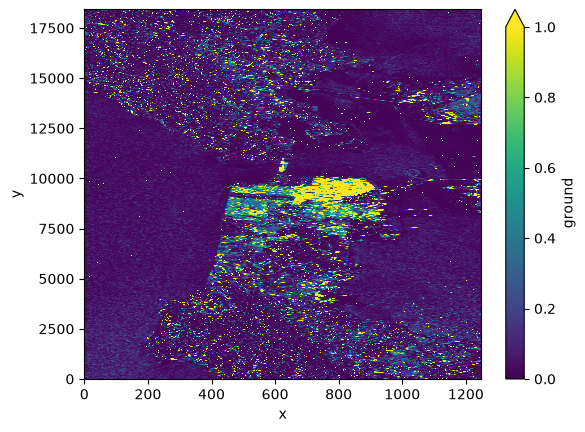

In [5]:
# ground component
res.ground.plot.imshow(vmin=0, vmax=1)

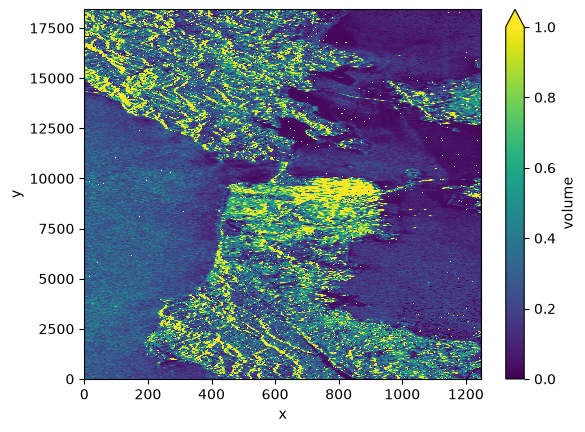

In [6]:
# volume component
res.volume.plot.imshow(vmin=0, vmax=1)